In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline 

#### The cv2 module in Python is part of the OpenCV (Open Source Computer Vision Library) library, which is a powerful open-source computer vision and machine learning software library. OpenCV provides a wide range of functionalities for image and video processing, including:

In [2]:
img=cv2.imread("C:\\Users\\dhruv\\OneDrive\\Desktop\\Face_Recognition\\model\\dataset\\maria_sarapoa\\95349717081091468_hv3jryev_f.jpg")
img.shape

(877, 584, 3)

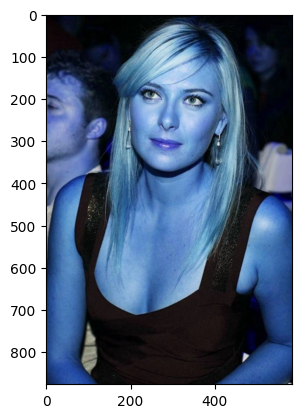

In [3]:
plt.imshow(img)

#### Remove colors and changing it on gray


In [4]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(877, 584)

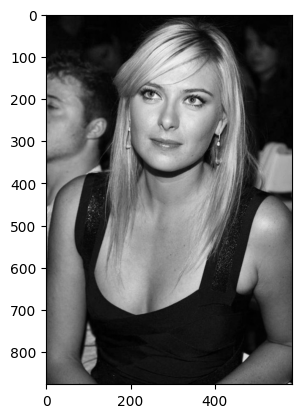

In [5]:
plt.imshow(gray,cmap='gray') #colormap gray is used to when image is gray 

### face recognistion (2eyes 1 lips ) by harcassade

In [6]:
face_cascade=cv2.CascadeClassifier("./opencv/haarcascade_frontalface_default.xml") #./ means this file is in same directory

In [7]:
eye_cascade=cv2.CascadeClassifier("./opencv/haarcascade_eye.xml")

In [8]:
faces = face_cascade.detectMultiScale(gray,1.3,5) # 1.3 is ScaleFactor which will reduce size of image by 30
faces                                             #5 is a candidate rectangle will only be considered a valid face detection if it has at least 5 overlapping rectangles in its vicinity.

array([[162,  92, 273, 273]], dtype=int32)

In [9]:
(x,y,w,h)=faces[0] # faces is the list and the coordinates of the frist one is shown . it unpack the coordinates
x,y,w,h

(np.int32(162), np.int32(92), np.int32(273), np.int32(273))

### now rectangle the face by using unpack coordinates

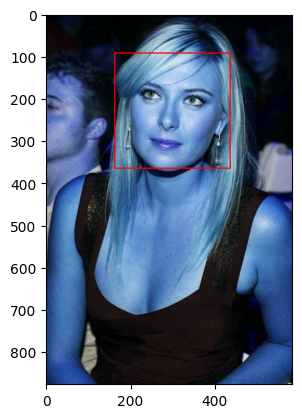

In [10]:
face_img=cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

In [11]:
cv2.destroyAllWindows() #imshow open new windows pop off that why to close it is used
for(x,y,w,h) in faces:
    face_img=cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray=gray[y:y+h,x:x+w]
    roi_color=face_img[y:y+h,x:x+w]
    eyes=eye_cascade.detectMultiScale(roi_gray,scaleFactor=1.1, minNeighbors=10)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),3)
#Detection is done in roi_gray because Haar cascades work better with grayscale images.
#Drawing is done in roi_color because we want the final output in color.

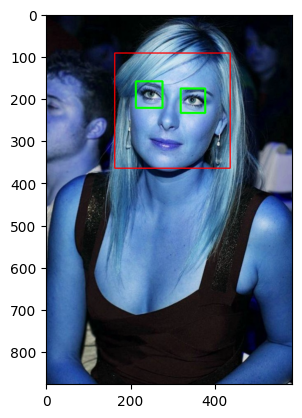

In [12]:
plt.figure()
plt.imshow(face_img,cmap='gray')
plt.show()

### roi_gray = gray[y:y + h//2, x:x + w]  # Only detect eyes in the upper half
### roi_color = img[y:y + h//2, x:x + w]


### Same code function but it is for all images

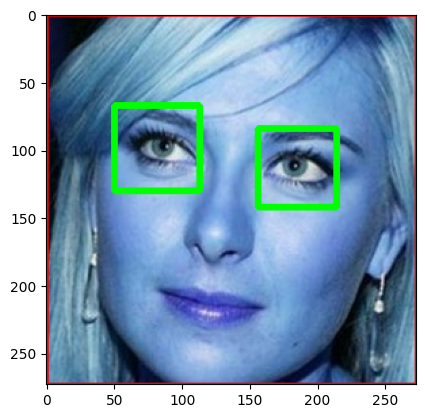

In [13]:
%matplotlib inline 
plt.imshow(roi_color,cmap='gray')

In [14]:
def get_cropped_image_if_2_eyes(image_path):
    img=cv2.imread(image_path)
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces=face_cascade.detectMultiScale(gray,1.3,5)
    for(x,y,w,h) in faces:
        roi_gray=gray[y:y+h,x:x+w] #Extracts the face region from the grayscale image.
        roi_color=img[y:y+h,x:x+w]
        eyes=eye_cascade.detectMultiScale(roi_gray)
        if len(eyes)>=2:
            return roi_color

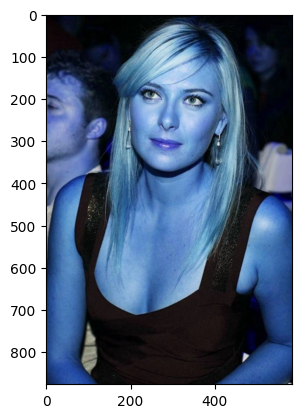

In [15]:
original_image=cv2.imread("C:\\Users\\dhruv\\OneDrive\\Desktop\\Face_Recognition\\model\\dataset\\maria_sarapoa\\95349717081091468_hv3jryev_f.jpg")
plt.imshow(original_image)

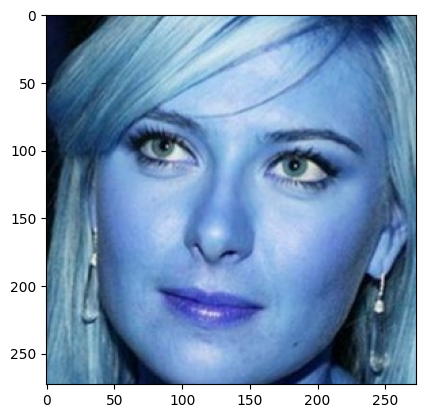

In [16]:
cropped_image=get_cropped_image_if_2_eyes("C:\\Users\\dhruv\\OneDrive\\Desktop\\Face_Recognition\\model\\dataset\\maria_sarapoa\\95349717081091468_hv3jryev_f.jpg")
plt.imshow(cropped_image)

#### after cropping all images we have to store it on a different folder name: Cropped_folder

In [17]:
path_to_data="./dataset/"
path_to_cr_data="./dataset/cropped/"

In [18]:
import os
img_dirs=[]
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
img_dirs

['./dataset/cropped',
 './dataset/maria_sarapoa',
 './dataset/messsi',
 './dataset/roger',
 './dataset/serena',
 './dataset/virat_kholi']

#### To genrate Cropped Directory

In [19]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

#### To ireate our fuction to each directories

In [20]:
cropped_img_dir=[]
celebrity_file_name_dict={}
for img_dir in img_dirs:
    count=1
    celebrity_name=img_dir.split('/')[-1]
    print(celebrity_name)
    celebrity_file_name_dict[celebrity_name]=[]
    for entry in os.scandir(img_dir):
        roi_color=get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder=path_to_cr_data + celebrity_name
            if not os.path.exists (cropped_folder):
                os.makedirs(cropped_folder)
                cropped_img_dir.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)

            cropped_file_name=celebrity_name + str(count) + ".png"
            cropped_file_path=cropped_folder + "/" + cropped_file_name
            cv2.imwrite(cropped_file_path,roi_color)
            celebrity_file_name_dict[celebrity_name].append(cropped_file_path)
            count+=1
# we have to manually delete error img like blur or friends img

cropped
maria_sarapoa
Generating cropped images in folder:  ./dataset/cropped/maria_sarapoa
messsi
Generating cropped images in folder:  ./dataset/cropped/messsi
roger
Generating cropped images in folder:  ./dataset/cropped/roger
serena
Generating cropped images in folder:  ./dataset/cropped/serena
virat_kholi
Generating cropped images in folder:  ./dataset/cropped/virat_kholi


### After cleaning we will do feature eng by Wavelet Transform (frequency domain, fourier transform )

In [21]:
cropped_img = np.array(roi_color)
cropped_img.shape

(124, 124, 3)

In [22]:
import numpy as np
import pywt
import cv2

def w2d(img,mode="haar",level=1): #"haar" is one of the simplest wavelet transformations used for edge detection and compression.level=1:Defines the decomposition level (how many times the wavelet transform is applied).
    imArray=img
    #Datatype conversion #convert to grayscale
    imArray=cv2.cvtColor(imArray,cv2.COLOR_BGR2GRAY)

    #convert to float
    imArray=np.float32(imArray)
    imArray = np.float32(imArray) / 255.0  

    # Compute 2D Discrete Wavelet Transform (DWT)
    coeffs = pywt.wavedec2(imArray, mode, level=level) 

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] = np.zeros_like(coeffs_H[0])

    #Reconstruction
    imArray_H=pywt.waverec2(coeffs_H,mode);
    imArray_H*=255;
    imArray_H=np.uint8(imArray_H)

    return imArray_H

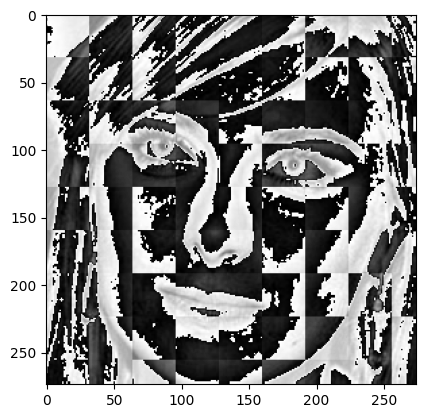

In [23]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har, cmap='gray')

#### NOw we will stack org img and b/w img  

In [24]:
celebrity_file_name_dict

{'cropped': [],
 'maria_sarapoa': ['./dataset/cropped/maria_sarapoa/maria_sarapoa1.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa2.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa3.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa4.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa5.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa6.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa7.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa8.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa9.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa10.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa11.png',
  './dataset/cropped/maria_sarapoa/maria_sarapoa12.png'],
 'messsi': ['./dataset/cropped/messsi/messsi1.png',
  './dataset/cropped/messsi/messsi2.png',
  './dataset/cropped/messsi/messsi3.png',
  './dataset/cropped/messsi/messsi4.png',
  './dataset/cropped/messsi/messsi5.png',
  './dataset/cropped/messsi/messsi6.png',
  './dataset/cropped/messsi/m

In [25]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_name_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'cropped': 0,
 'maria_sarapoa': 1,
 'messsi': 2,
 'roger': 3,
 'serena': 4,
 'virat_kholi': 5}

In [26]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_name_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])     

In [27]:
# X=[]
# y=[]
# for celebrity_name ,training_files in celebrity_file_name_dict.items():
#     for training_image in training_files:
#         img=cv2.imread(training_image)
#         if img is None :
#             continue
            
#         #resize the image
#         scalled_raw_img = cv2.resize(img, (32, 32))
#         img_har=w2d(img,mode='db1',level=5)
#         scalled_img_har = cv2.resize(img_har, (32, 32))

#         #Vertically Stacked Both Images
#         combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
#         X.append(combined_img)
#         y.append(class_dict[celebrity_name])

In [28]:
len(X)

59

In [29]:
len(X[0])

4096

In [30]:
X=np.array(X).reshape(len(X),4096).astype(float)

In [31]:
X.shape

(59, 4096)

In [32]:
X[0]

array([152., 174., 198., ...,  50.,   0.,   0.])

## trainn our model


In [33]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [34]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2,random_state=3,stratify=y)
print(len(X_test), len(y_test)) 

12 12


In [35]:
pipe=Pipeline([
    ("Scaler",StandardScaler()),
    ("SVC",SVC(kernel='rbf',C=10))
])

In [36]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('Scaler', StandardScaler()), ('SVC', SVC(C=10))])

In [37]:
pipe.score(X_test,y_test)

0.75

In [38]:
print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.33      0.50      0.40         2
           3       1.00      0.50      0.67         2
           4       0.75      1.00      0.86         3
           5       1.00      0.67      0.80         3

    accuracy                           0.75        12
   macro avg       0.82      0.73      0.74        12
weighted avg       0.83      0.75      0.76        12



In [39]:
from collections import Counter
print(Counter(y_train))  # Show class distribution


Counter({4: 10, 5: 10, 1: 10, 2: 10, 3: 7})


In [40]:
y_pred=pipe.predict(X_test)

In [42]:
import numpy as np
print("Unique classes in y_test:", np.unique(y_test))
print("Unique classes in y_pred:", np.unique(y_pred))



Unique classes in y_test: [1 2 3 4 5]
Unique classes in y_pred: [1 2 3 4 5]


In [43]:
import numpy as np

y_test = np.array(y_test)  # Convert list to NumPy array
y_pred = np.array(y_pred)  # Convert list to NumPy array

print(f"y_test shape: {y_test.shape}")
print(f"y_pred shape: {y_pred.shape}")


y_test shape: (12,)
y_pred shape: (12,)


In [45]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[2, 0, 0, 0, 0],
       [0, 1, 0, 1, 0],
       [0, 1, 1, 0, 0],
       [0, 0, 0, 3, 0],
       [0, 1, 0, 0, 2]])

#### lets use grid search to try out different models with parameters": goal is to come up with best model with best PArameter tunning

In [46]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [66]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [67]:
scores=[]
best_estimators={}
import pandas as pd
for algo,mp in model_params.items():
    pipe=make_pipeline(
        StandardScaler(),mp['model']
    )
    clf=GridSearchCV(pipe,mp['params'],cv=5,return_train_score=False)
    clf.fit(X_train,y_train)
    scores.append({
        'model':algo,
        'Best_score':clf.best_score_,
        'Best_params':clf.best_params_,
    })
    best_estimators[algo]=clf.best_estimator_

C:\Users\dhruv\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dhruv\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dhruv\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\dhruv\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_mo

In [68]:
df=pd.DataFrame(scores,columns=['model','Best_score','Best_params'])
df

,model,Best_score,Best_params
0,svm,0.597778,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.575556,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.682222,{'logisticregression__C': 1}


In [85]:
best_clf=best_estimators['svm']
best_clf

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=1, gamma='auto', kernel='linear', probability=True))])

In [86]:
best_estimators['svm'].score(X_test,y_test)

0.6666666666666666

In [87]:
best_estimators['random_forest'].score(X_test,y_test)

0.75

In [88]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.75

In [89]:
best_clf = best_estimators['svm']

In [90]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[2, 0, 0, 0, 0],
       [0, 1, 0, 1, 0],
       [1, 0, 1, 0, 0],
       [0, 0, 0, 3, 0],
       [0, 1, 1, 0, 1]])

In [91]:

# Predict using the best model
y_pred = best_clf.predict(X_test)

Text(95.72222222222221, 0.5, 'Truth')

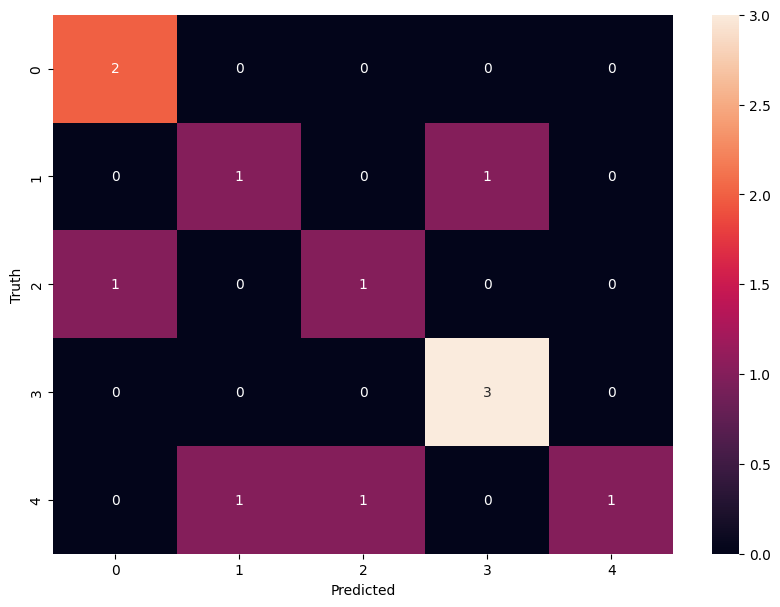

In [92]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
import joblib
joblib.dump()